YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


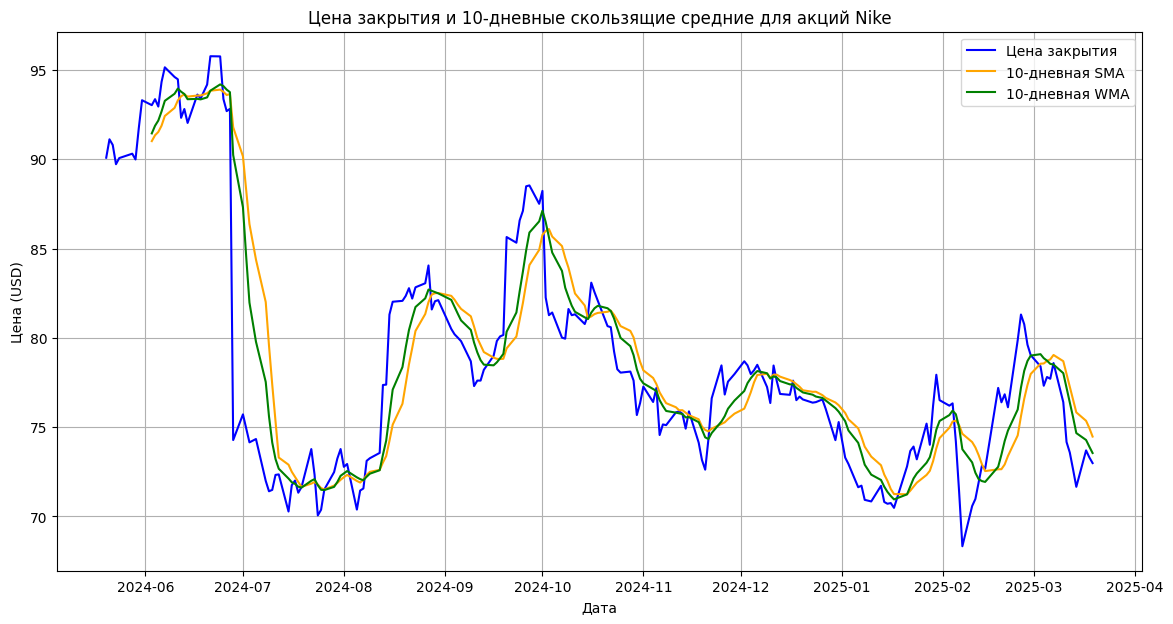

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных по акциям Nike за последние 10 месяцев
ticker = 'NKE'
data = yf.download(ticker, period='10mo', interval='1d')

# Вычисление 10-дневной простой скользящей средней (SMA)
data['SMA_10'] = data['Close'].rolling(window=10).mean()

# Вычисление 10-дневной взвешенной скользящей средней (WMA)
weights = pd.Series(range(1, 11))
data['WMA_10'] = data['Close'].rolling(window=10).apply(lambda prices: (prices * weights).sum() / weights.sum(), raw=True)

# Построение графика
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Цена закрытия', color='blue')
plt.plot(data.index, data['SMA_10'], label='10-дневная SMA', color='orange')
plt.plot(data.index, data['WMA_10'], label='10-дневная WMA', color='green')
plt.title('Цена закрытия и 10-дневные скользящие средние для акций Nike')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

В общем и целом, скользящие среднии реагируют на изменения направления движения графика на протяжении всего периода. Можно отметить наиболее точные и приближенные реакции скользящих средних на изменения: 2024-09, 2024-10.

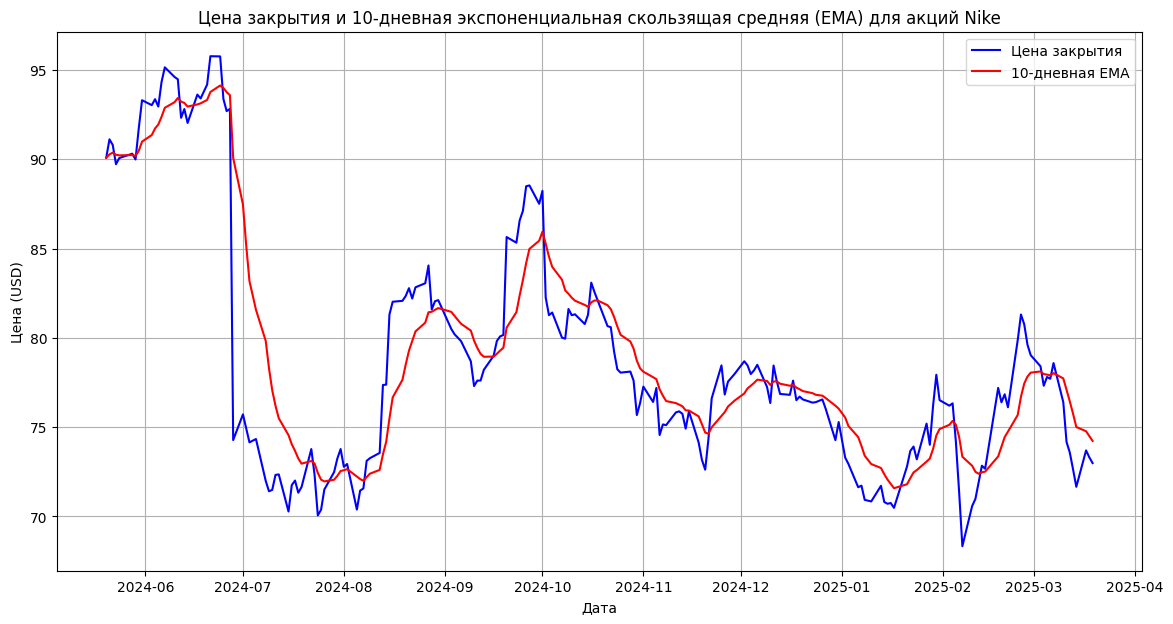

In [ ]:
# Вычисление 10-дневной экспоненциальной скользящей средней (EMA)
data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()

# Построение графика
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Цена закрытия', color='blue')
plt.plot(data.index, data['EMA_10'], label='10-дневная EMA', color='red')
plt.title('Цена закрытия и 10-дневная экспоненциальная скользящая средняя (EMA) для акций Nike')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

На графике представлена 10-дневная экспоненциальная скользящая средняя (EMA) в сравнении с фактической ценой закрытия акций Nike. EMA, будучи индикатором тренда, демонстрирует сглаженные движения цены, что помогает выявить ключевые развороты и тенденции.
В начале периода наблюдается рост цены, сопровождающийся уверенным движением EMA вверх. Это может быть связано с позитивными финансовыми результатами, маркетинговыми кампаниями или общим восстановлением потребительского спроса.
Резкое падение в середине графика указывает на сильное негативное событие, например, отчет о снижении прибыли, макроэкономические проблемы или негативные новости, касающиеся компании.
Восстановление цены в сентябре-октябре сопровождается EMA, но видно, что скользящая средняя отстает от резких скачков цены, что типично для индикаторов тренда.
В конце графика наблюдается волатильность и снижение цены, EMA следует за трендом, но сглаживает резкие колебания.

Nike, как глобальная компания, чувствительна к ряду факторов:
Финансовые показатели – публикация квартальных отчетов может влиять на цену акций. Снижение цены может указывать на разочаровывающие результаты или слабый прогноз.
Макроэкономические условия – инфляция, ставки ФРС, потребительские расходы и уровень безработицы могут влиять на покупательскую способность и доходы компании.
Конкуренция и рынок – акции могут реагировать на новости о конкурентах, запуске новых продуктов и маркетинговых стратегиях.
Геополитические и логистические факторы – например, задержки поставок, торговые ограничения или изменения в производственных цепочках.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

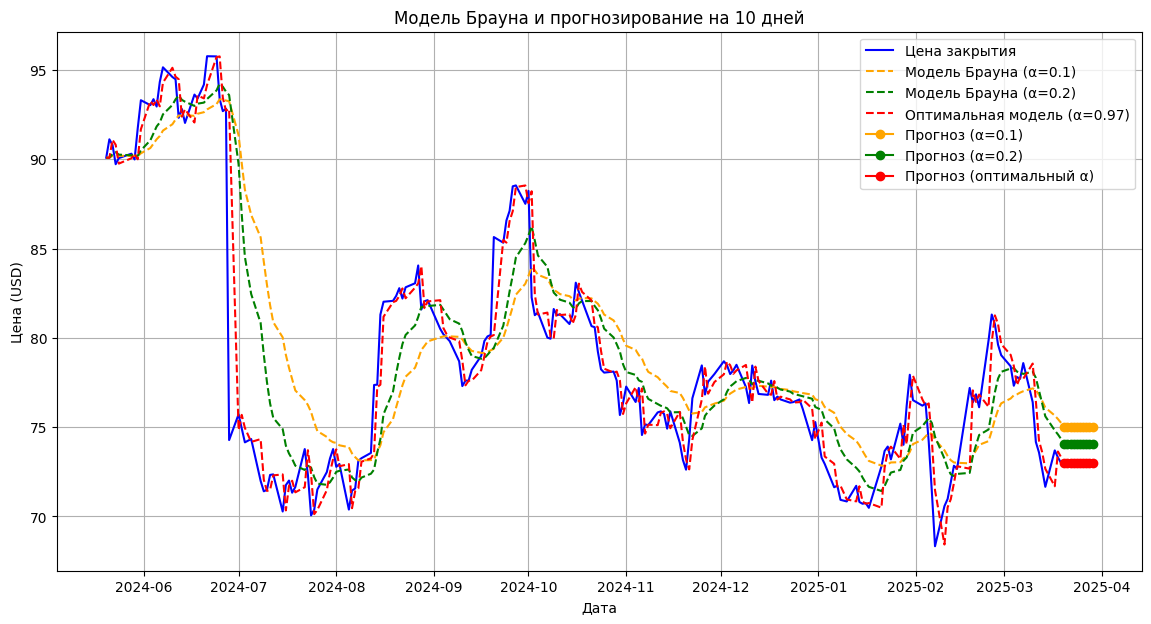

Оптимальное значение α: 0.9694


In [ ]:
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Выбираем только цену закрытия
close_prices = data['Close']

# Функция для построения модели Брауна и прогнозирования
def brown_model_forecast(series, alpha, steps=10):
    model = SimpleExpSmoothing(series).fit(smoothing_level=alpha, optimized=False)
    forecast = model.forecast(steps)
    return model.fittedvalues, forecast

# Модель Брауна с alpha = 0.1
fitted_01, forecast_01 = brown_model_forecast(close_prices, alpha=0.1)

# Модель Брауна с alpha = 0.2
fitted_02, forecast_02 = brown_model_forecast(close_prices, alpha=0.2)

# Оптимальная модель (автоматический подбор alpha)
opt_model = SimpleExpSmoothing(close_prices).fit(optimized=True)
opt_alpha = opt_model.model.params['smoothing_level']
fitted_opt, forecast_opt = opt_model.fittedvalues, opt_model.forecast(10)

# Построение графиков
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Цена закрытия', color='blue')
plt.plot(close_prices.index, fitted_01, label='Модель Брауна (α=0.1)', linestyle='dashed', color='orange')
plt.plot(close_prices.index, fitted_02, label='Модель Брауна (α=0.2)', linestyle='dashed', color='green')
plt.plot(close_prices.index, fitted_opt, label=f'Оптимальная модель (α={opt_alpha:.2f})', linestyle='dashed', color='red')

# Добавляем прогноз на 10 дней
future_dates = pd.date_range(close_prices.index[-1], periods=11, freq='D')[1:]
plt.plot(future_dates, forecast_01, 'o-', label='Прогноз (α=0.1)', color='orange')
plt.plot(future_dates, forecast_02, 'o-', label='Прогноз (α=0.2)', color='green')
plt.plot(future_dates, forecast_opt, 'o-', label='Прогноз (оптимальный α)', color='red')

plt.title('Модель Брауна и прогнозирование на 10 дней')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Вывод подобранного моделью alpha
print(f'Оптимальное значение α: {opt_alpha:.4f}')

Оптимальное значение α = 0.9694:
Модель с этим α (красная пунктирная линия) наиболее точно следует за фактическими ценами закрытия.
Она хорошо реагирует на резкие изменения, но при этом не слишком шумная — видно, что она наиболее точно отслеживает тренды.

Оптимальная модель даёт наиболее адекватное продолжение текущего движения, находясь ближе всего к последним точкам фактических данных.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

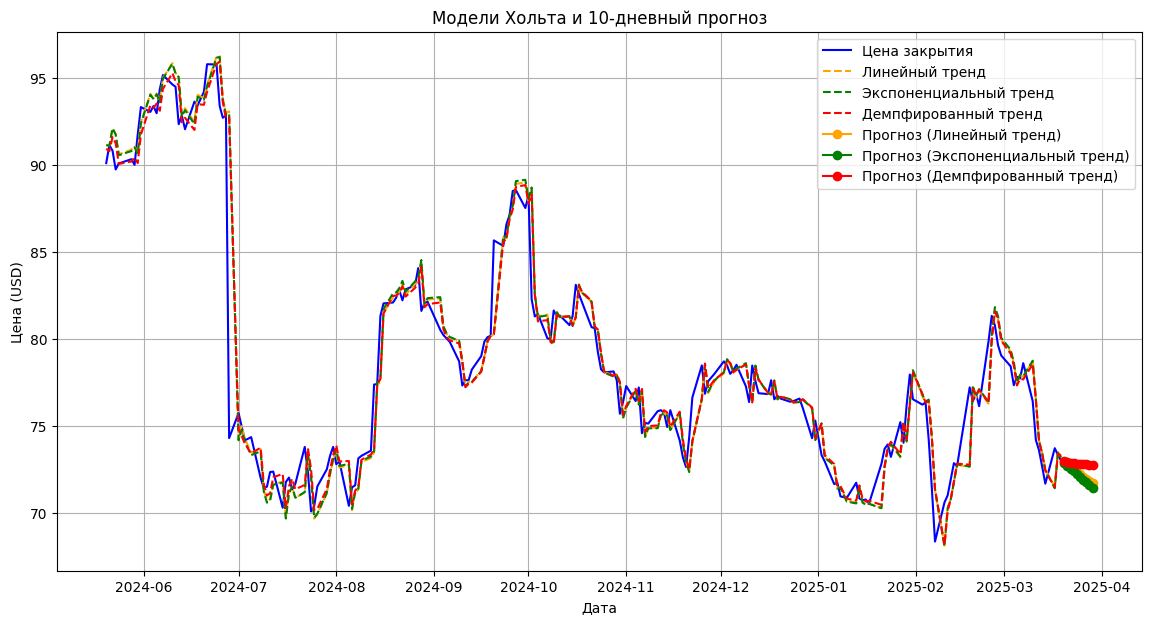

Параметры линейного тренда: {'smoothing_level': np.float64(0.9646171449313095), 'smoothing_trend': np.float64(0.05586629902797156), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(90.0887222290039), 'initial_trend': np.float64(1.03076171875), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
Параметры экспоненциального тренда: {'smoothing_level': np.float64(0.9537283293163473), 'smoothing_trend': np.float64(0.07527626570789207), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(90.0887222290039), 'initial_trend': np.float64(1.0114416287993278), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
Параметры демпфированного тренда: {'smoothing_level': np.float64(0.8853054415462893), 'smoothing_trend': np.float64(0.11732061649267572), 'smoothing_seasonal': np.float64(nan), 'damping_trend': np.float64(0.8), 'i

In [ ]:
from statsmodels.tsa.holtwinters import Holt
# Выбираем только цену закрытия
close_prices = data['Close']

# Функция для построения модели Хольта и прогнозирования
def holt_model_forecast(series, exponential=False, damped=False, steps=10):
    model = Holt(series, exponential=exponential, damped_trend=damped).fit(optimized=True)
    forecast = model.forecast(steps)
    return model.fittedvalues, forecast, model.model.params

# Модель Хольта с линейным трендом
fitted_linear, forecast_linear, params_linear = holt_model_forecast(close_prices, exponential=False, damped=False)

# Модель Хольта с экспоненциальным трендом
fitted_exp, forecast_exp, params_exp = holt_model_forecast(close_prices, exponential=True, damped=False)

# Модель Хольта с аддитивным демпфированным трендом
fitted_damped, forecast_damped, params_damped = holt_model_forecast(close_prices, exponential=False, damped=True)

# Построение графиков
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Цена закрытия', color='blue')
plt.plot(close_prices.index, fitted_linear, label='Линейный тренд', linestyle='dashed', color='orange')
plt.plot(close_prices.index, fitted_exp, label='Экспоненциальный тренд', linestyle='dashed', color='green')
plt.plot(close_prices.index, fitted_damped, label='Демпфированный тренд', linestyle='dashed', color='red')

# Добавляем прогноз на 10 дней
future_dates = pd.date_range(close_prices.index[-1], periods=11, freq='D')[1:]
plt.plot(future_dates, forecast_linear, 'o-', label='Прогноз (Линейный тренд)', color='orange')
plt.plot(future_dates, forecast_exp, 'o-', label='Прогноз (Экспоненциальный тренд)', color='green')
plt.plot(future_dates, forecast_damped, 'o-', label='Прогноз (Демпфированный тренд)', color='red')

plt.title('Модели Хольта и 10-дневный прогноз')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Вывод параметров моделей
print("Параметры линейного тренда:", params_linear)
print("Параметры экспоненциального тренда:", params_exp)
print("Параметры демпфированного тренда:", params_damped)

Модель Хольта с демпфированным трендом наиболее полезна в данной ситуации — она сбалансирована между чувствительностью и устойчивостью, хорошо подходит для краткосрочного прогноза.

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

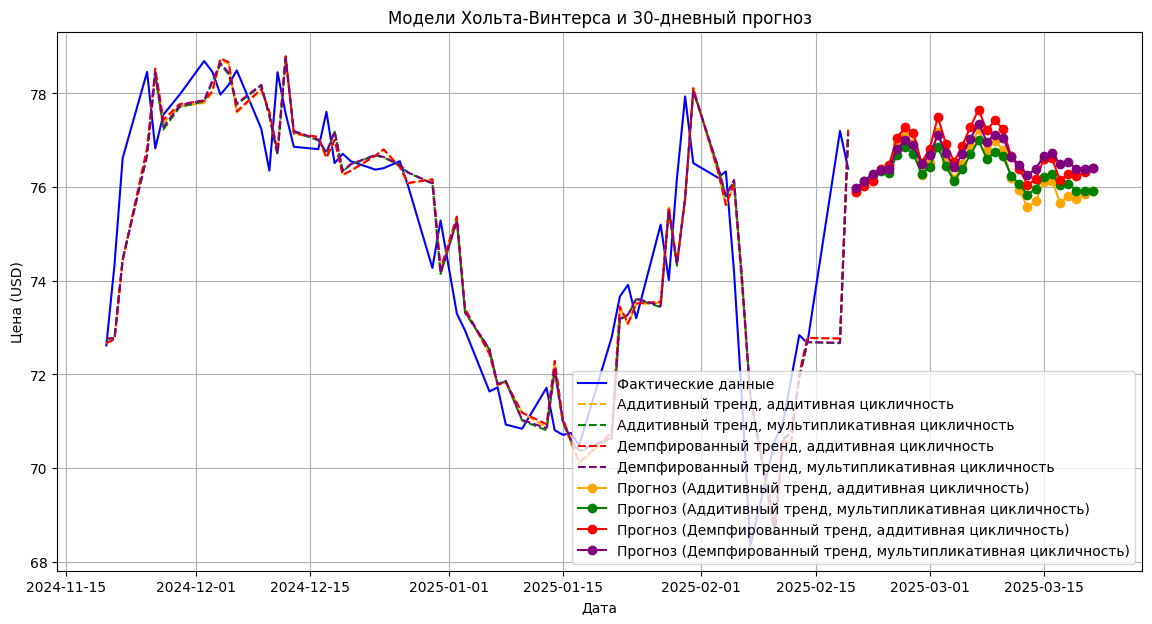

Параметры модели (Аддитивный тренд, Аддитивная цикличность): {'smoothing_level': np.float64(0.9900523515363043), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(95.85087377062395), 'initial_trend': np.float64(-0.015803547043100826), 'initial_seasons': array([ 0.45486866,  0.49725845,  1.03985305,  1.23102681,  1.07280588,
        0.42096188,  0.69485731,  1.36095567,  0.77931479,  0.38731061,
        0.7345556 ,  1.13451307,  1.50338357,  1.0687545 ,  1.2840172 ,
        1.10748031,  0.53057401,  0.2812995 , -0.05967647,  0.07205828,
        0.51349071,  0.54685991,  0.09715167,  0.24350836,  0.2086819 ,
        0.31980158,  0.41635307, -0.07718193,  0.07106177,  0.19594155]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
Параметры модели (Аддитивный тренд, Мультипликативная цикличность): {'smoothing_level': np.float64(0.9903366457563546), 'smoothing_trend': np.float64(4.434640075232395e-11), 'smoo

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Загрузка данных по акциям Nike за последние 5 лет (до месяца назад)
ticker = 'NKE'
end_date = pd.to_datetime("today") - pd.DateOffset(months=1)
start_date = end_date - pd.DateOffset(years=5)
data = yf.download(ticker, start=start_date, end=end_date, interval='1d')

# Выбираем только цену закрытия
close_prices = data['Close']

# Функция для построения модели Хольта-Винтерса и прогнозирования
def hw_model_forecast(series, trend, seasonal, damped, steps=30, seasonal_periods=30):
    model = ExponentialSmoothing(series, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods, damped_trend=damped).fit()
    forecast = model.forecast(steps)
    return model.fittedvalues, forecast, model.model.params

# Построение моделей
fitted_add_add, forecast_add_add, params_add_add = hw_model_forecast(close_prices, trend='add', seasonal='add', damped=False)
fitted_add_mul, forecast_add_mul, params_add_mul = hw_model_forecast(close_prices, trend='add', seasonal='mul', damped=False)
fitted_damped_add, forecast_damped_add, params_damped_add = hw_model_forecast(close_prices, trend='add', seasonal='add', damped=True)
fitted_damped_mul, forecast_damped_mul, params_damped_mul = hw_model_forecast(close_prices, trend='add', seasonal='mul', damped=True)

# Последние 60 дней данных и прогноз на 30 дней
last_60_days = close_prices[-60:]
future_dates = pd.date_range(last_60_days.index[-1], periods=31, freq='D')[1:]

# Построение графиков
plt.figure(figsize=(14, 7))
plt.plot(last_60_days.index, last_60_days, label='Фактические данные', color='blue')
plt.plot(last_60_days.index, fitted_add_add[-60:], label='Аддитивный тренд, аддитивная цикличность', linestyle='dashed', color='orange')
plt.plot(last_60_days.index, fitted_add_mul[-60:], label='Аддитивный тренд, мультипликативная цикличность', linestyle='dashed', color='green')
plt.plot(last_60_days.index, fitted_damped_add[-60:], label='Демпфированный тренд, аддитивная цикличность', linestyle='dashed', color='red')
plt.plot(last_60_days.index, fitted_damped_mul[-60:], label='Демпфированный тренд, мультипликативная цикличность', linestyle='dashed', color='purple')

# Добавляем прогноз на 30 дней
plt.plot(future_dates, forecast_add_add, 'o-', label='Прогноз (Аддитивный тренд, аддитивная цикличность)', color='orange')
plt.plot(future_dates, forecast_add_mul, 'o-', label='Прогноз (Аддитивный тренд, мультипликативная цикличность)', color='green')
plt.plot(future_dates, forecast_damped_add, 'o-', label='Прогноз (Демпфированный тренд, аддитивная цикличность)', color='red')
plt.plot(future_dates, forecast_damped_mul, 'o-', label='Прогноз (Демпфированный тренд, мультипликативная цикличность)', color='purple')

plt.title('Модели Хольта-Винтерса и 30-дневный прогноз')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Вывод параметров моделей
print("Параметры модели (Аддитивный тренд, Аддитивная цикличность):", params_add_add)
print("Параметры модели (Аддитивный тренд, Мультипликативная цикличность):", params_add_mul)
print("Параметры модели (Демпфированный тренд, Аддитивная цикличность):", params_damped_add)
print("Параметры модели (Демпфированный тренд, Мультипликативная цикличность):", params_damped_mul)

Наилучший результат по точности показывает модель с демпфированным трендом и аддитивной сезонностью.
Прогноз этой модели показывает умеренный рост с сохранением сезонной структуры, без чрезмерных выбросов.
Мультипликативная сезонность (особенно без демпфирования) в данном случае чрезмерно усиливает колебания и может вводить в заблуждение при оценке рисков.

Покупательская активность стабилизировалась, и рынок "встроил в цену" основные драйверы роста.
Nike может столкнуться с умеренным спросом, особенно в условиях высоких процентных ставок и давления на потребителей.
Отсутствие ярко выраженного восходящего тренда говорит о возможном ожидании инвесторов: им нужны новые сигналы (отчетность, прогнозы по Китаю, динамика спроса на премиум-сегмент).
При этом сезонные пики повторяются, что говорит о здоровой потребительской структуре продаж — компания не теряет устойчивости.